In [2]:
import pandas as pd

In [5]:
orders = pd.read_excel("data/orders.xlsx")
products = pd.read_excel("data/products.xlsx")

In [4]:
orders.head()

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74
1,1517430051,2022-01-13 16:46:53,17122,1,169,169,74
2,1517578174,2022-01-13 18:12:30,17122,1,169,169,74
3,1517466327,2022-01-13 15:11:12,22199,1,219,219,130
4,1517429157,2022-01-13 19:15:59,22199,1,219,219,130


In [6]:
products.head()

,product_id,level1,level2,name
0,1,Гигиена,Бритье,Кассеты для бритья Gillette Fusion ProGlide Po...
1,2,Мучные кондитерские изделия,Мучные кондитерские изделия,Печенье Бодрость
2,3,Мясная гастрономия,"Сосиски, сардельки",Сосиски Стародворье
3,4,Чай,Черный чай,Чай Азерчай
4,5,Безалкогольные напитки,Соковая продукция,Морс Valio


# 1 Task

Самая ходовая товарная группа
По какой категории товаров продано больше всего позиций?

Подкрепите свой ответ таблицей, в которой рассчитано количество проданных штук товара в каждой товарной категории.
Дополнительно постройте на основании этой таблицы barchart.
Проверьте, чтобы все подписи на вашем графике выглядели читаемо и понятно. Этот график должен быть сходу понятен стороннему наблюдателю.

In [8]:
df1 = orders.merge(products, on="product_id", how="left")

df1.head(1)

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price,level1,level2,name
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан


In [10]:
res1 = df1.groupby("level1")["quantity"].sum().sort_values(ascending=False)

res1

level1
Безалкогольные напитки          534
Молочная продукция              483
Свежие овощи                    262
Кулинария                       250
Бакалея                         239
Хлеб и хлебобулочные изделия    218
Снэки                           212
Свежие фрукты                   184
Замороженная продукция          175
Кондитерские изделия            138
Мучные кондитерские изделия     124
Сыры                            114
Продукция для животных          113
Мясная гастрономия              112
Детское питание                  96
Птица                            90
Гигиена                          77
Консервированные продукты        74
Рыбная гастрономия               44
Яичные товары                    40
Чай                              40
Мясо                             29
Уход                             24
Бытовая химия                    23
Кофе, какао                      21
Рыба                              8
Детство (Гигиена и Уход)          6
Специальное питание  

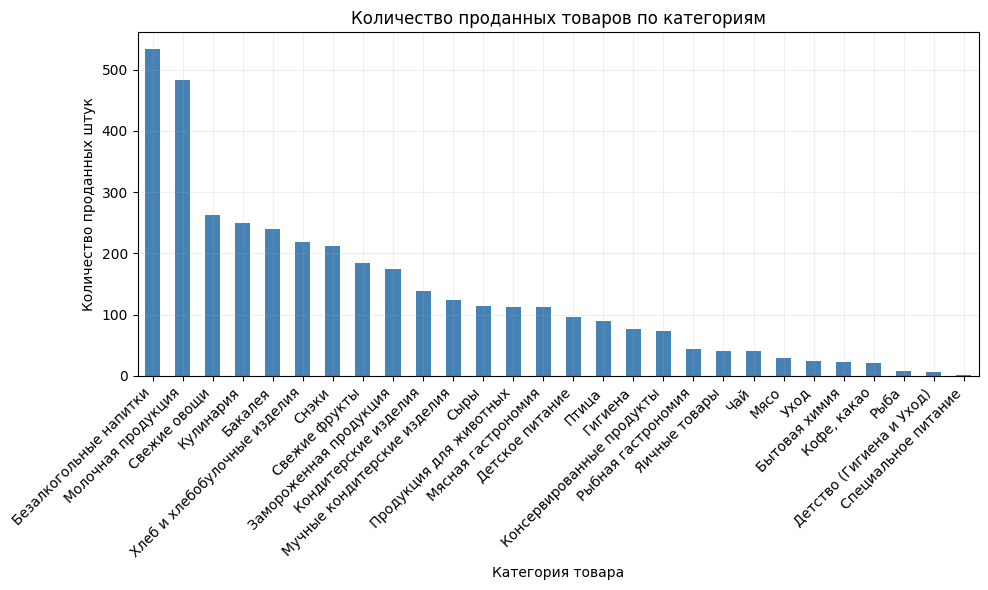

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
res1.plot(kind="bar", color="steelblue")
plt.title("Количество проданных товаров по категориям")
plt.xlabel("Категория товара")
plt.ylabel("Количество проданных штук")
plt.xticks(rotation=45, ha="right")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# 2 Task

Распределение продаж по подкатегориям
Оцените распределение количества проданных позиций в каждой товарной категории (level1) по подкатегориям (level2). Проиллюстрируйте свой результат расчетной таблицей.